In [6]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "/Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR/PMGControlsEditedDec2021/34/34control1/34control1_cor_0_099.jpg"
PREPROCESSED_PATH = "/Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR_minimal/controlcases/34/34control1/34control1_cor_0_135_preprocessed_minimal.jpg"


BASE = os.path.abspath(os.path.join(os.path.dirname("__file__"), "..", "data"))
PRE_CTRL_DIR = os.path.join(
    BASE,
    "PPMR_minimal/PMGcases/controlcases/34/34control1/34control1_cor_0_135_preprocessed_minimal.jpg",
)
CTRL_DIR = os.path.join(
    BASE, "PPMR/PMGControlsEditedDec2021/34/34control1/34control1_cor_0_099.jpg"
)

print("PMG  dir:", PRE_CTRL_DIR, "→ exists:", os.path.isdir(PRE_CTRL_DIR))
print("CTRL dir:", CTRL_DIR, "→ exists:", os.path.isdir(CTRL_DIR))

PMG  dir: /Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR_minimal/PMGcases/controlcases/34/34control1/34control1_cor_0_135_preprocessed_minimal.jpg → exists: False
CTRL dir: /Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR/PMGControlsEditedDec2021/34/34control1/34control1_cor_0_099.jpg → exists: False


In [7]:
# --- Load images ---
raw_rgb = Image.open(RAW_PATH)  #  raw
raw_gray = raw_rgb.convert("L")  # 1 channel
raw_back = raw_gray.convert("RGB")
pre_rgb = Image.open(PREPROCESSED_PATH).convert("RGB")

arr_raw = np.array(raw_rgb)[..., 0]
arr_gray = np.array(raw_gray)  # 1 channel
arr_back = np.array(raw_back)[..., 0]
arr_pre = np.array(pre_rgb)[..., 0]

print(
    "Raw RGB    mode:",
    raw_rgb.mode,
    "| shape:",
    np.array(raw_rgb).shape,
    "| R==G:",
    np.array_equal(np.array(raw_rgb)[..., 0], np.array(raw_rgb)[..., 1]),
)
print("Gray       mode:", raw_gray.mode, "| shape:", np.array(raw_gray).shape)
print(
    "Back RGB   mode:",
    raw_back.mode,
    "| shape:",
    np.array(raw_back).shape,
    "| R==G:",
    np.array_equal(np.array(raw_back)[..., 0], np.array(raw_back)[..., 1]),
)
print("Preprocess mode:", pre_rgb.mode, "| shape:", np.array(pre_rgb).shape)

PMG_PRE_PATH = "/Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR_minimal/PMGcases/34/34cor_1/34cor_1_50_2_preprocessed_minimal.jpg"
pmg_pre = Image.open(PMG_PRE_PATH).convert("RGB")
arr_pmg_pre = np.array(pmg_pre)[..., 0]
print("PMG Pre    mode:", pmg_pre.mode, "| shape:", np.array(pmg_pre).shape)

Raw RGB    mode: RGB | shape: (320, 260, 3) | R==G: True
Gray       mode: L | shape: (320, 260)
Back RGB   mode: RGB | shape: (320, 260, 3) | R==G: True
Preprocess mode: RGB | shape: (320, 260, 3)
PMG Pre    mode: RGB | shape: (1727, 1508, 3)


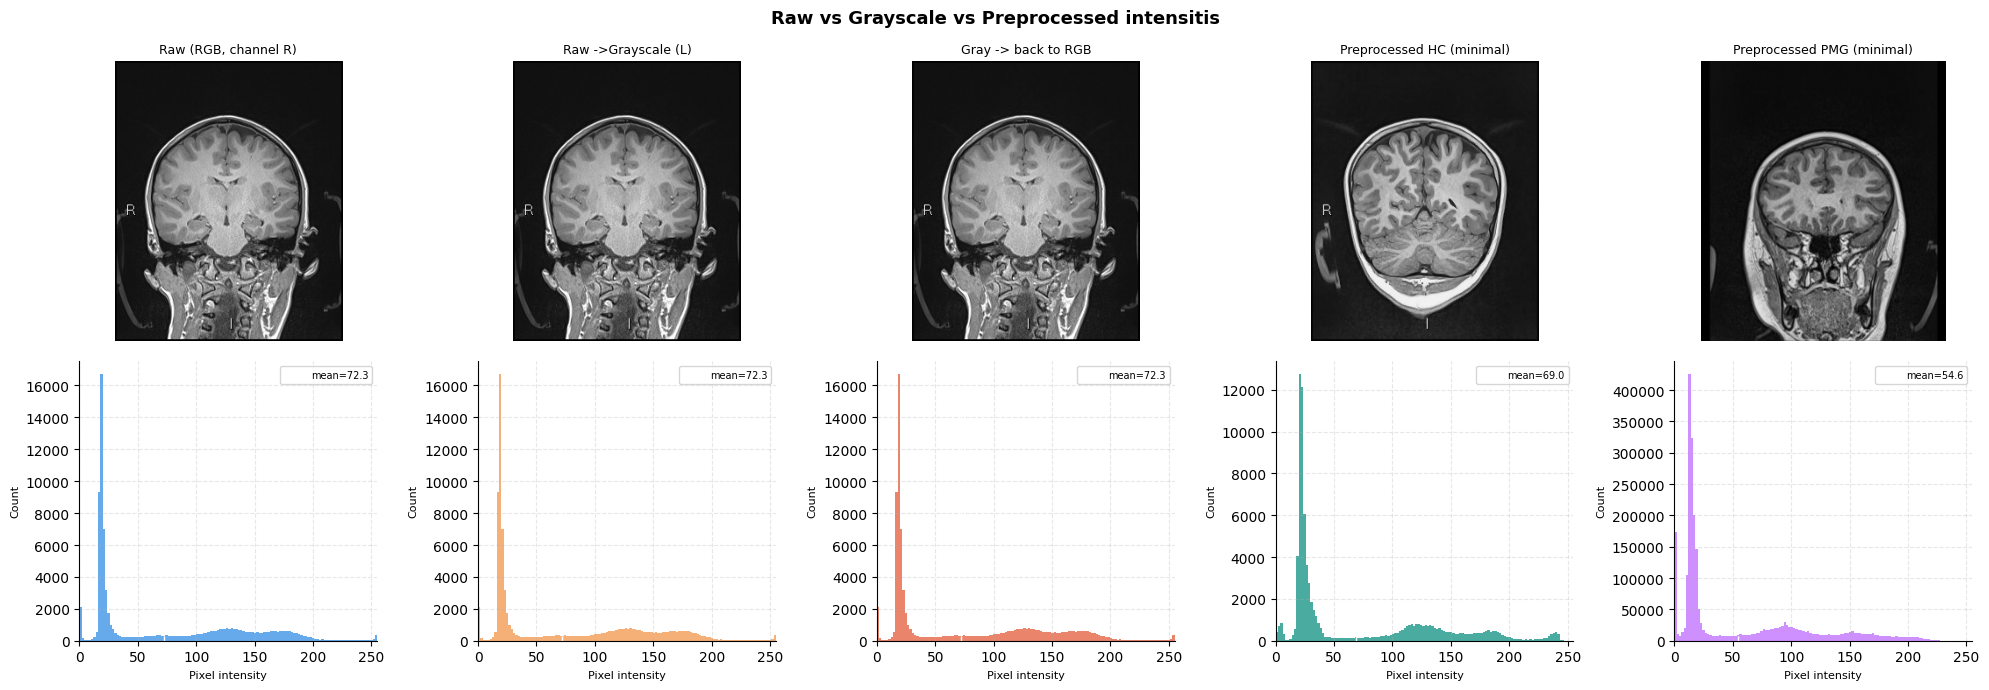

Saved _> intensity_distribution.png


In [8]:
# --- Plot ---
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle(
    "Raw vs Grayscale vs Preprocessed intensitis", fontsize=13, fontweight="bold"
)

images = [
    (arr_raw, "Raw (RGB, channel R)", "#4C9BE8"),
    (arr_gray, "Raw ->Grayscale (L)", "#F4A261"),
    (arr_back, "Gray -> back to RGB", "#E76F51"),
    (arr_pre, "Preprocessed HC (minimal)", "#2A9D8F"),
    (arr_pmg_pre, "Preprocessed PMG (minimal)", "#C77DFF"),
]

for col, (arr, title, color) in enumerate(images):
    axes[0, col].imshow(arr, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].hist(
        arr.flatten(),
        bins=128,
        range=(0, 255),
        color=color,
        alpha=0.85,
        edgecolor="none",
    )
    axes[1, col].set_xlabel("Pixel intensity", fontsize=8)
    axes[1, col].set_ylabel("Count", fontsize=8)
    axes[1, col].set_xlim(0, 255)
    axes[1, col].grid(True, linestyle="--", alpha=0.3)
    axes[1, col].spines[["top", "right"]].set_visible(False)
    mean_val = arr.mean()
    axes[1, col].axvline(
        mean_val,
        color="white",
        linestyle="--",
        linewidth=1,
        label=f"mean={mean_val:.1f}",
    )
    axes[1, col].legend(fontsize=7)

plt.tight_layout()
plt.savefig("intensity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved _> intensity_distribution.png")